# Fashion MNIST CNN Workshop
Train a CNN from scratch using TensorFlow/Keras.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.19.1
NumPy: 2.1.3


In [2]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.fashion_mnist.load_data()
print(x_train.shape,x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28) (10000, 28, 28)


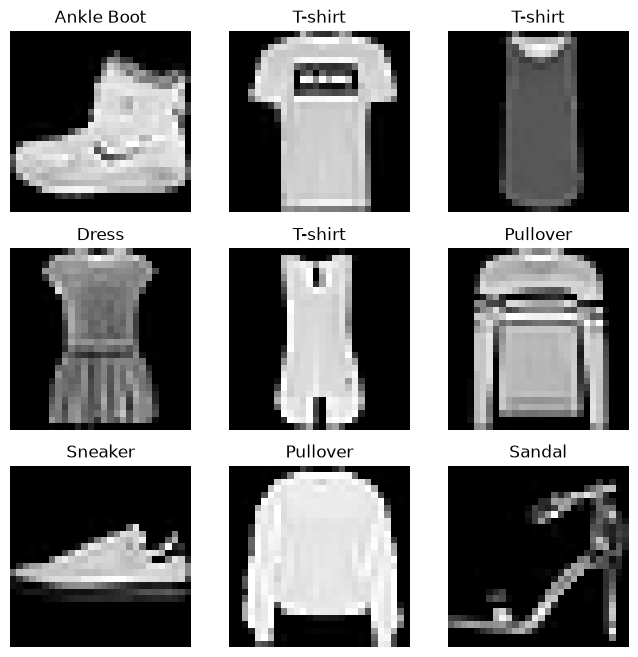

In [3]:
class_names=['T-shirt','Trouser','PullovSer','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle Boot']
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i],cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [4]:
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0
x_train=x_train[...,None]
x_test=x_test[...,None]

In [6]:
model=tf.keras.Sequential([
tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
tf.keras.layers.MaxPooling2D(),
tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
tf.keras.layers.MaxPooling2D(),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(128,activation='relu'),
tf.keras.layers.Dropout(0.5),
tf.keras.layers.Dense(10,activation='softmax')
])
model.summary()

C:\Users\sadiq\anaconda3\envs\deep_learning\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
history=model.fit(x_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step - accuracy: 0.7943 - loss: 0.5729 - val_accuracy: 0.8597 - val_loss: 0.3841
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.8637 - loss: 0.3800 - val_accuracy: 0.8884 - val_loss: 0.3076
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.8795 - loss: 0.3348 - val_accuracy: 0.8932 - val_loss: 0.2820
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.8885 - loss: 0.3043 - val_accuracy: 0.8991 - val_loss: 0.2657
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.8975 - loss: 0.2814 - val_accuracy: 0.9027 - val_loss: 0.2599


In [8]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print(test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8968 - loss: 0.2768
0.8967999815940857


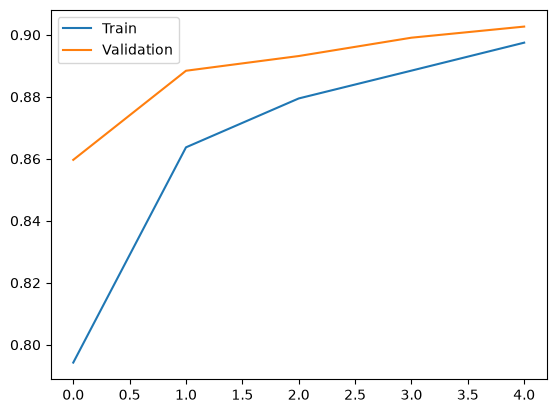

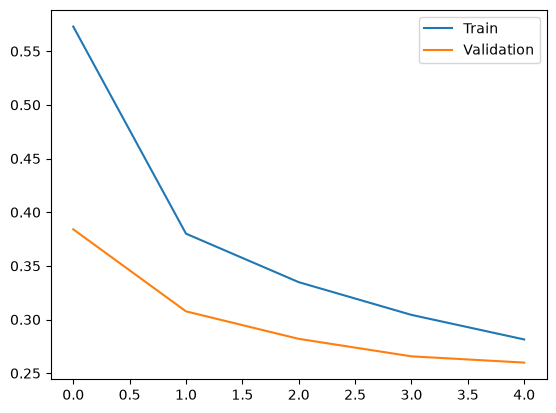

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.show()

In [10]:
pred=model.predict(x_test[:5])
for i,p in enumerate(pred):
    print("Actual:",class_names[y_test[i]],"Pred:",class_names[np.argmax(p)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
Actual: Ankle Boot Pred: Ankle Boot
Actual: Pullover Pred: Pullover
Actual: Trouser Pred: Trouser
Actual: Trouser Pred: Trouser
Actual: Shirt Pred: Shirt


In [11]:
model.save("fashion_mnist_cnn.keras")
print("Saved.")

Saved.


## Fine-tuning Exercises
- Change filters 32/64 to 64/128.
- Train for 10 or 20 epochs.
- Change optimizer to RMSprop or SGD.
- Change dropout to 0.3.
- Add BatchNormalization layers.
